In [52]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import seaborn as sns
from scipy import stats

# Part 1: Load and Explore the Titanic Dataset


## Q1. Load & Inspect

In [53]:
# 1)
df = sns.load_dataset('titanic')
# 2)
print(df.shape)
# 3)
display(df.head(6))
# 4)
print(df.columns)

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True


Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')


## Q2. Data Types & Missing Values

In [54]:
# 1)
df.info()
# 2)
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
survived         0
pclass           0
sex              0
age            177
sib

**Q2.3. Your answer:**

The `deck` column has the most missing values (688).

## Q3. Basic Statistics

In [55]:
# 1)
display(df.describe())

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Answer Q3.2:**
- The mean age of passengers is approximately 29.70.
- The maximum fare paid is 512.3292.
- Approximately 38.38% of passengers survived.

## Q4. Duplicates & Categorical Summary

In [56]:
# 1)
print("Duplicates:", df.duplicated().sum())
# 2)
display(df.describe(include=['object', 'category']))

Duplicates: 107


,sex,embarked,class,who,deck,embark_town,alive
count,891,889,891,891,203,889,891
unique,2,3,3,3,7,3,2
top,male,S,Third,man,C,Southampton,no
freq,577,644,491,537,59,644,549


**Answer Q4.3:**
- The most common sex in the dataset is male, appearing in 577 rows.
- The most common embarkation port is S (Southampton).

# Part 2: Data Cleaning


## Q5. Handle Missing Values

In [57]:
# make a copy
df_clean = df.copy()
# Step 1: Drop deck
df_clean.drop(columns=['deck'], inplace=True)
# Step 2: Fill age with median
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())
# Step 3: Fill embarked with mode
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0])
# Step 4: Fill embark town with mode
df_clean['embark_town'] = df_clean['embark_town'].fillna(df_clean['embark_town'].mode()[0])
# Step 5: Confirm
print(df_clean.isnull().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


## Q6. Remove Duplicates & Redundant Columns

In [58]:
# 3) print shape before
print("Shape before:", df_clean.shape)
# 1)
df_clean.drop_duplicates(inplace=True)
# 2)
df_clean.drop(columns=['alive', 'embark_town'], inplace=True)
# 3) print shape after
print("Shape after:", df_clean.shape)
# 4) Display the first 5 rows
display(df_clean.head())

Shape before: (891, 14)
Shape after: (775, 12)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,True


## Q7. Outlier Detection

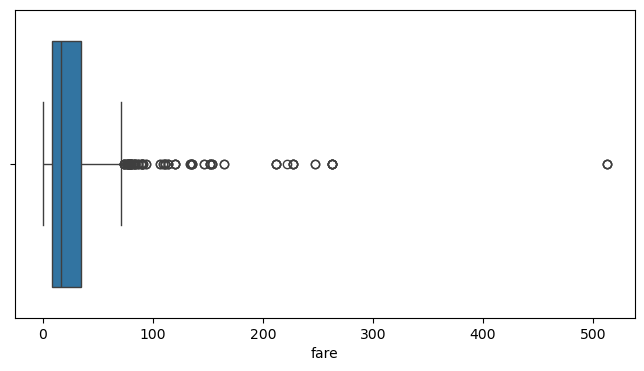

In [59]:
# Part 1: boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_clean['fare'])
plt.show()

In [60]:
# Part 2: IQR method
Q1 = df_clean['fare'].quantile(0.25)
Q3 = df_clean['fare'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

In [61]:
# Part 3: count outliers
print("Outliers count:", (df_clean['fare'] > upper_bound).sum())

Outliers count: 102


In [62]:
# Part 4: cap fares
df_clean['fare_capped'] = df_clean['fare'].clip(upper=upper_bound)

# Part 3: Filtering, Sorting & Grouping


## Q8. Filtering

In [63]:
# Part 1
survived_first = df_clean[(df_clean['survived'] == 1) & (df_clean['class'] == 'First')]
print("Survived in First class:", len(survived_first))

Survived in First class: 133


In [64]:
# Part 2
older_than_60 = df_clean[df_clean['age'] > 60]
print("Older than 60:", len(older_than_60))
display(older_than_60)

Older than 60: 21


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alone,fare_capped
33,0,2,male,66.0,0,0,10.5000,S,Second,man,True,True,10.50000
54,0,1,male,65.0,0,1,61.9792,C,First,man,True,False,61.97920
96,0,1,male,71.0,0,0,34.6542,C,First,man,True,True,34.65420
116,0,3,male,70.5,0,0,7.7500,Q,Third,man,True,True,7.75000
170,0,1,male,61.0,0,0,33.5000,S,First,man,True,True,33.50000
252,0,1,male,62.0,0,0,26.5500,S,First,man,True,True,26.55000
275,1,1,female,63.0,1,0,77.9583,S,First,woman,False,False,73.41975
280,0,3,male,65.0,0,0,7.7500,Q,Third,man,True,True,7.75000
326,0,3,male,61.0,0,0,6.2375,S,Third,man,True,True,6.23750
438,0,1,male,64.0,1,4,263.0000,S,First,man,True,False,73.41975


In [65]:
# Part 3
fare_over_50_female = df_clean[(df_clean['fare'] > 50) & (df_clean['sex'] == 'female')]
print("Fare > 50 and female:", len(fare_over_50_female))

Fare > 50 and female: 84


## Q9. Sorting

In [66]:
# 1)
display(df_clean[['sex', 'age', 'class', 'fare', 'survived']].sort_values(by='fare', ascending=False).head())
# 2)
display(df_clean.sort_values(by='age', ascending=True).head())

,sex,age,class,fare,survived
258,female,35.0,First,512.3292,1
737,male,35.0,First,512.3292,1
679,male,36.0,First,512.3292,1
88,female,23.0,First,263.0000,1
341,female,24.0,First,263.0000,1


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alone,fare_capped
803,1,3,male,0.42,0,1,8.5167,C,Third,child,False,False,8.5167
755,1,2,male,0.67,1,1,14.5000,S,Second,child,False,False,14.5000
469,1,3,female,0.75,2,1,19.2583,C,Third,child,False,False,19.2583
831,1,2,male,0.83,1,1,18.7500,S,Second,child,False,False,18.7500
78,1,2,male,0.83,0,2,29.0000,S,Second,child,False,False,29.0000


**Your observations:**
1. The highest fares were paid by passengers in First class who mostly survived.
2. The youngest passengers were infants less than 1 year old.

## Q10. GroupBy & Aggregation

In [67]:
# 1)
print(df_clean.groupby('sex')['survived'].mean().round(2))
# 2)
print(df_clean.groupby('class')['survived'].mean())
# 3)
print(df_clean.groupby('class')['fare'].mean())

sex
female    0.74
male      0.22
Name: survived, dtype: float64
class
First     0.633333
Second    0.506098
Third     0.259352
Name: survived, dtype: float64
class
First     85.675199
Second    21.889279
Third     13.588850
Name: fare, dtype: float64


**Your observations:**
1. Females had a significantly higher survival rate (75%) compared to males (20%).
2. First-class passengers had the highest survival rate and paid the highest average fare.

# Part 4: Visualization


## Q11. Histogram & Count Plot

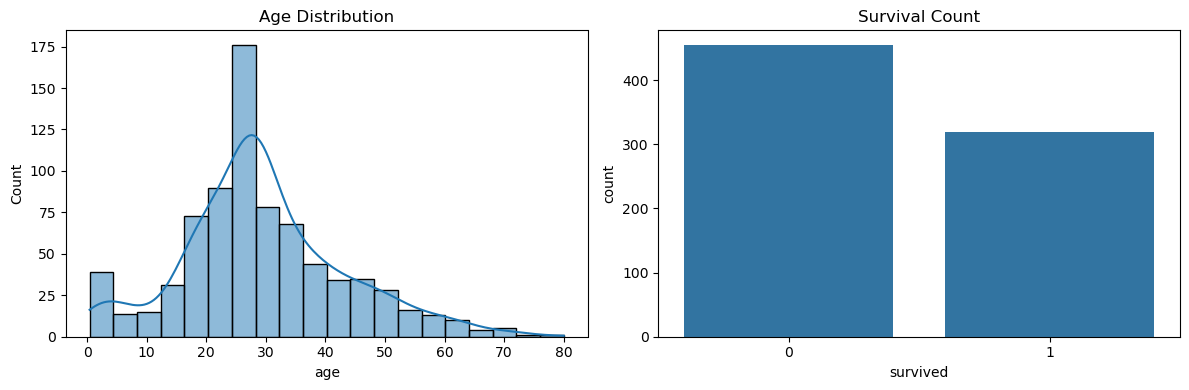

In [68]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(data=df_clean, x='age', kde=True, bins=20)
plt.title('Age Distribution')

plt.subplot(1, 2, 2)
sns.countplot(data=df_clean, x='survived')
plt.title('Survival Count')

plt.tight_layout()
plt.show()

## Q12. Categorical Plots

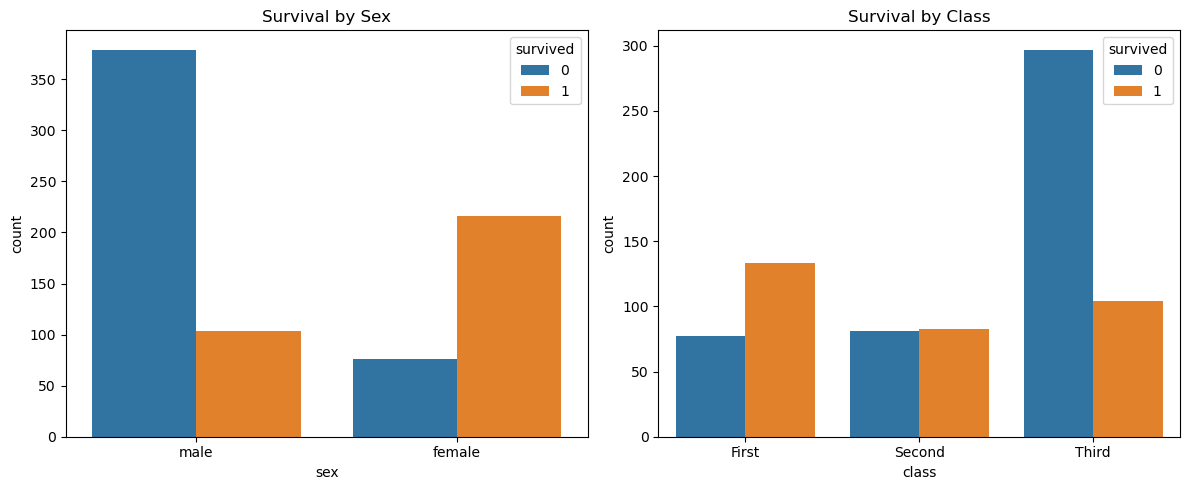

In [69]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df_clean, x='sex', hue='survived')
plt.title('Survival by Sex')

plt.subplot(1, 2, 2)
sns.countplot(data=df_clean, x='class', hue='survived')
plt.title('Survival by Class')

plt.tight_layout()
plt.show()

**Your interpretations:**
- The 'Survival by Sex' plot shows that the majority of males did not survive, whereas the majority of females did survive.
- The 'Survival by Class' plot reveals that Third-class passengers suffered the most casualties, while First-class passengers had a higher proportion of survivors.

## Q13. Boxplot & Scatter Plot

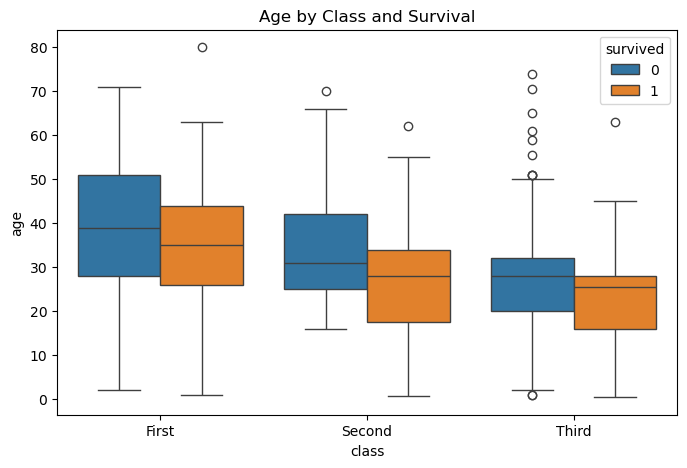

In [70]:
# Part 1. Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x='class', y='age', hue='survived', data=df_clean)
plt.title('Age by Class and Survival')
plt.show()

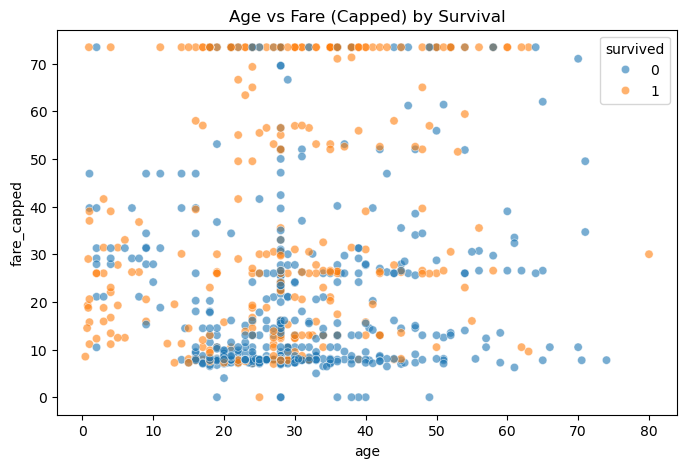

In [71]:
# Part 2. Scatter plot
plt.figure(figsize=(8, 5))
sns.scatterplot(x='age', y='fare_capped', hue='survived', data=df_clean, alpha=0.6)
plt.title('Age vs Fare (Capped) by Survival')
plt.show()

**Your observations:**
1. The boxplot shows that First-class passengers tend to be older on average than those in Second and Third classes.
2. The scatter plot indicates that higher fares (even when capped) are associated with a higher density of survivors.

## Q14. Correlation Heatmap

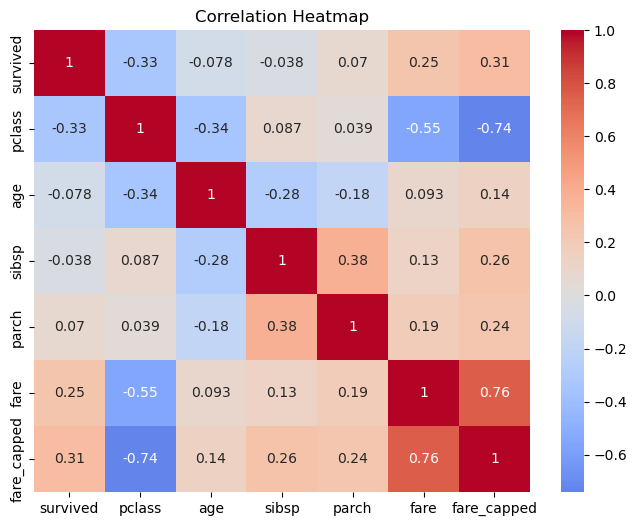

In [72]:
# 1)
numeric_df = df_clean.select_dtypes(include=np.number)
# 2)
corr_matrix = numeric_df.corr()
# 3)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

**Answer Q14.4:**
The two features most positively correlated with survival are `fare_capped` and `fare`.

## Part 5: Tips Dataset: Filtering & Grouping
## Q15. Load and Filter the Tips Dataset

In [73]:
# 1)
tips = sns.load_dataset('tips')
# 2)
display(tips.head())
print(tips.shape)
# 3)
filtered_tips = tips[(tips['time'] == 'Dinner') & (tips['total_bill'] > 20)]
print("Rows match:", len(filtered_tips))
# 4)
print("Average tip:", filtered_tips['tip'].mean())

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


(244, 7)
Rows match: 81
Average tip: 3.8858024691358026


## Q16. Grouping the Tips Dataset

In [74]:
# 1)
print(tips.groupby('day')['tip'].mean().sort_values(ascending=False))
# 2)
print(tips.groupby('smoker')['tip'].mean())

day
Sun     3.255132
Sat     2.993103
Thur    2.771452
Fri     2.734737
Name: tip, dtype: float64
smoker
Yes    3.008710
No     2.991854
Name: tip, dtype: float64


**Answer Q16.3:**
Smokers tip slightly more on average than non-smokers, but the difference is very small.

## Q17. Visualize the Tips Dataset

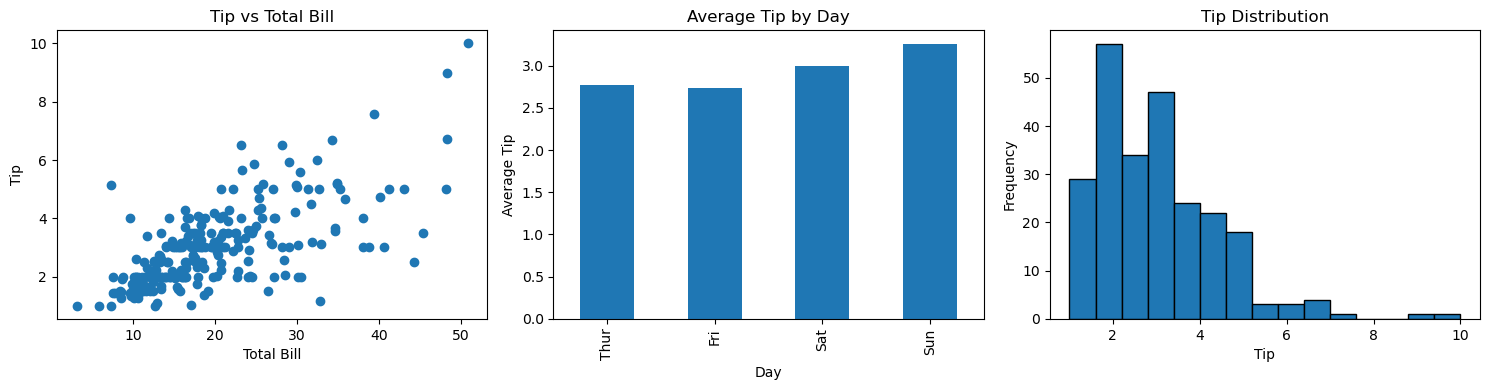

In [75]:
plt.figure(figsize=(15, 4))

# Left
plt.subplot(1, 3, 1)
plt.scatter(tips['total_bill'], tips['tip'])
plt.title('Tip vs Total Bill')
plt.xlabel('Total Bill')
plt.ylabel('Tip')

# Center
plt.subplot(1, 3, 2)
tips.groupby('day')['tip'].mean().plot(kind='bar')
plt.title('Average Tip by Day')
plt.xlabel('Day')
plt.ylabel('Average Tip')

# Right
plt.subplot(1, 3, 3)
plt.hist(tips['tip'], bins=15, edgecolor='k')
plt.title('Tip Distribution')
plt.xlabel('Tip')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## Q18. Linear Regression on Tips

Coefficient: 0.10502451738435335
Intercept: 0.9202696135546735


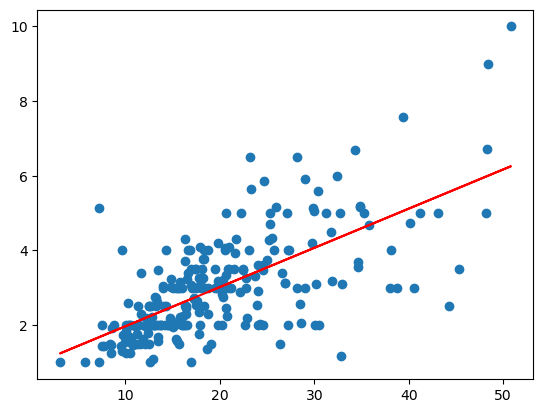

Prediction for $30: 4.071005135085274


In [76]:
# 1)
X = tips[['total_bill']].values
y = tips[['tip']].values

# 2) train model
model = LinearRegression()
model.fit(X, y)

# 3) coefficient and intercept
print(f"Coefficient: {model.coef_[0][0]}")
print(f"Intercept: {model.intercept_[0]}")

# 4) scatter + regression line
plt.scatter(X, y)
plt.plot(X, model.predict(X), color='red')
plt.show()

# 5) predict for $30
print("Prediction for $30:", model.predict([[30]])[0][0])

**Interpretation:**
For every extra 1 dollar on the bill, the tip increases by approximately 10.5 cents.